# **Distribucion del dinero**


*   Sin inflación
*   Con número de agentes constante
*   No inyectamos dinero al sistema
*   Con deuda




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Número de agentes
N = 100_000
#Dinero inicial
m_0 = 100
#Vector de agentes
M = np.ones(N)*m_0
#Cantidad maxima por intercambio
M_max = 100
d = 200 #deuda

In [ ]:
#Seleccionar dos agentes
def asig():
  count = 0
  while count == 0:
    x = np.random.randint(0,N,2)
    if x[0] != x[1]:
      count = 1
  return x

In [ ]:
count2 = 0 #contador de simulaciones
# Interacción entre agentes
#200 de deuda maxima
while count2 < 2e6:
  i,j = asig()
  delm = np.random.random()*M_max
  if M[j] + 200> delm:
    M[i] += delm
    M[j] -= delm
    count2 += 1



In [ ]:
#Guardar datos del vector de agentes en un archivo
#np.savetxt('dinero6.txt', M, fmt='%.6f')

# Datos generados

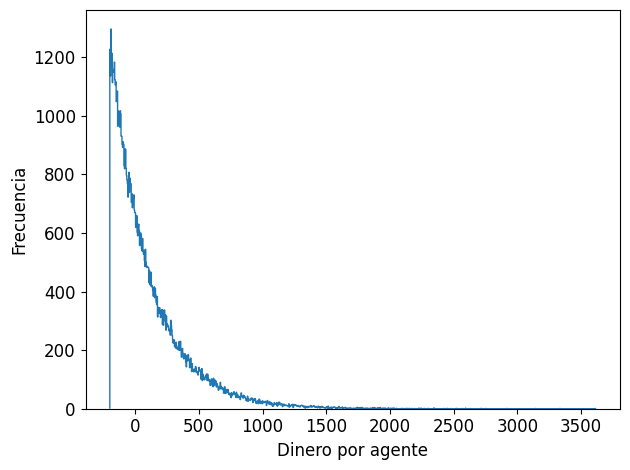

In [ ]:
#Obtener datos de las frecuencias
datos = pd.read_csv("Dinero_deuda_10_10_simulaciones.txt", header=None)
ydata = datos[0]

plt.hist(ydata, bins=1000, histtype='step')
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("hisgramadeuda1.jpg", dpi=200)

plt.show()




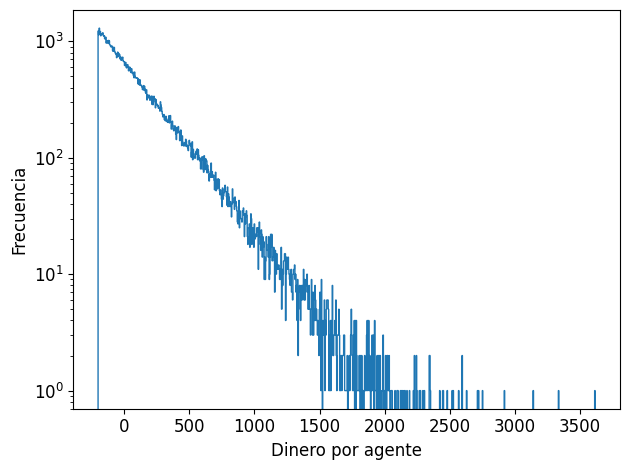

In [ ]:
# Crear histograma con escala logaritmica en las frecuencias
plt.hist(ydata, bins=1000, histtype='step', log=True)
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("hisgramadeuda2.jpg", dpi=300)
plt.show()

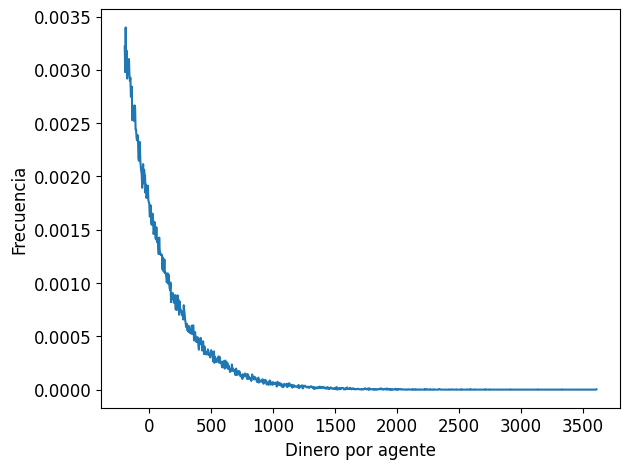

1.0


In [ ]:
#Normalizar el histograma
hist, bin_edges = np.histogram(datos, bins=1000)
dx = bin_edges[1] - bin_edges[0]
histnorm = hist / np.sum(hist * dx)
bins = bin_edges[:-1]
plt.plot(bins, histnorm)
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Frecuencia', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("hisgramadeudanorm.jpg", dpi=300)
plt.show()

#Comprobar la normalizacion
print(np.sum(histnorm*dx))

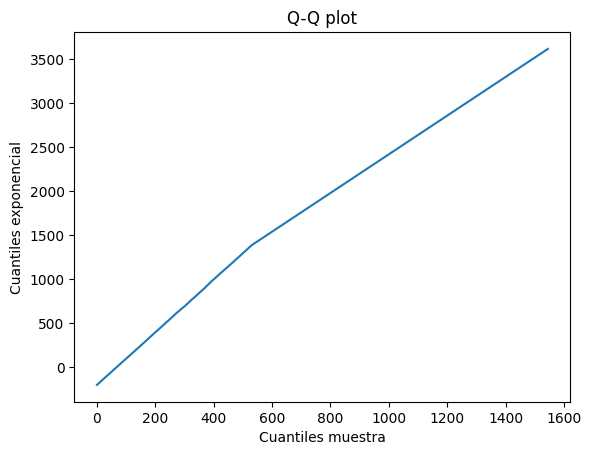

In [ ]:
#Q-Q plot
#Comparando los cuantiles de nuestra muestra y una muestra de una distribucion exponencial
N_1 = np.random.exponential(100,100_000)
N_2 = ydata
QN1 = np.quantile(N_1, np.linspace(0,1,200))
QN2 = np.quantile(N_2, np.linspace(0,1,200))

plt.plot(QN1, QN2)
plt.title('Q-Q plot')
plt.xlabel('Cuantiles muestra')
plt.ylabel('Cuantiles exponencial')
plt.show()


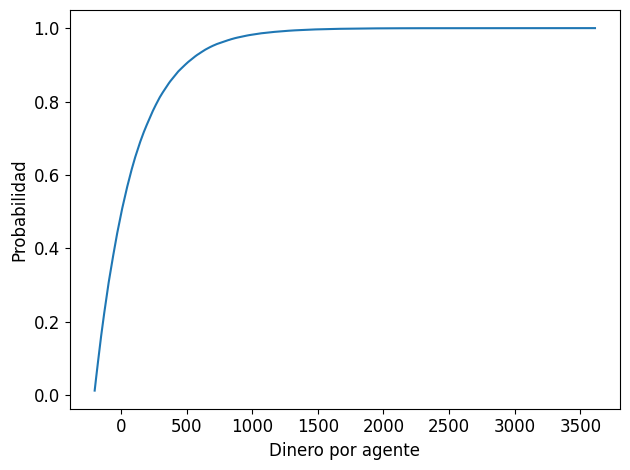

In [ ]:
#Grafica de la Probabilidad acumulada
yF = np.cumsum(histnorm*dx)
plt.plot(bins, yF)
plt.xlabel('Dinero por agente', fontsize = 12)
plt.ylabel('Probabilidad', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig("probacudeuda.jpg", dpi=300)
plt.show()

In [ ]:
#Prueba de Kolmogorov-Smirnov
from scipy import stats
from scipy.stats import kstest
from scipy.stats import ks_2samp
datos_positivos = ydata + d
#Muestra vs Distribucion
stat, p_value = kstest(datos_positivos,'expon', args=(0, 100 +d ))


print("Estadístico KS:", stat)
print("p-valor:", p_value)

alpha = 0.05
if p_value < alpha:
    print("\nRechazamos la hipótesis nula. Los datos NO parecen seguir una distribución exponencial.")
else:
    print("\nNo podemos rechazar la hipótesis nula. Los datos podrían provenir de una distribución exponencial.")


Estadístico KS: 0.0030095365103308125
p-valor: 0.32476049712180755

No podemos rechazar la hipótesis nula. Los datos podrían provenir de una distribución exponencial.


In [ ]:
#Muestra vs Muestra
y = np.random.exponential(100+d,10_000_000)
arr = np.asarray(ydata+d).ravel()

stat, p_value = ks_2samp(arr, y)
print("\nEstadístico KS:", stat)
print("p-valor:", p_value)


Estadístico KS: 0.002042499999999947
p-valor: 0.8024346600762777


El valor de a que maximiza el p-valor es 0.003324
El p-valor máximo es 0.6449


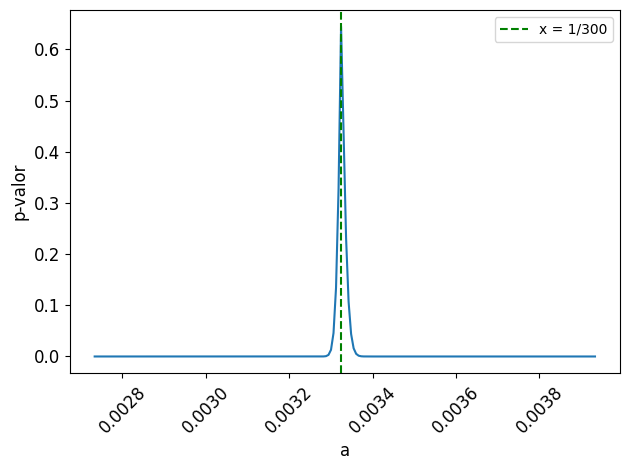

In [ ]:
#Grafica del p-valor vs. a
datos_n = np.asarray(ydata+d) #convertir el dataframa a un arreglo numpy
a_vector = np.linspace((1/(100+d))-0.0006,(1/(100+d))+0.0006,200)
p_values = np.zeros(len(a_vector))
plt.figure()
for i in range(len(a_vector)):
    _, p_values[i]= kstest(datos_n,'expon', args=(0, float(1/a_vector[i])))


max_p_index = np.argmax(p_values)  # índice del p-valor máximo
best_a = a_vector[max_p_index]     # valor de a correspondiente
max_p = p_values[max_p_index]
print(f"El valor de a que maximiza el p-valor es {best_a:.6f}")
print(f"El p-valor máximo es {max_p:.4f}")

plt.figure(3,6)
plt.plot(a_vector, p_values,)
plt.axvline(x=0.003325, color='g', linestyle='--', label='x = 1/300')
plt.xlabel('a', fontsize = 12)
plt.ylabel('p-valor', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.savefig("pvaloresdeuda.jpg", dpi=300)
plt.show()



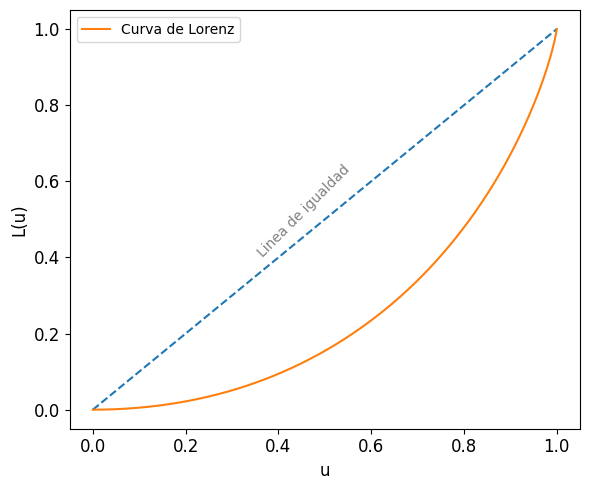

In [ ]:
# Grafica de la curva de Lorentz
def Lorentz(array):
    dinero = np.asarray(array, dtype=np.float64)
    n = array.shape[0] #número de agentes
    M_s = np.sort(dinero) #ordenamos las cantidades de dinero por agente
    y = np.cumsum(M_s)/(n*300) #obtenemos la porcion de dinero acumulado #m' = m_0 + d = 300
    x = np.linspace(0,1,n)

    return x,y

#Grafica de la curva de Lorentz para nuestra muestra y grafica de la linea de igualdad
plt.figure(figsize=(6,5))
x_1 = np.linspace(0,1,100)
plt.plot(x_1,x_1, '--')
x,y= Lorentz(ydata+200)

plt.plot(x,y, label = 'Curva de Lorenz')
x_pos = 0.35
y_pos = x_pos + 0.05

plt.text(x_pos, y_pos, 'Linea de igualdad', rotation=45, color='gray', fontsize=10)
plt.xlabel('u', fontsize = 12)
plt.ylabel('L(u)', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.legend()
plt.savefig("curvalorenzdeuda.jpg", dpi=300)
plt.show()


In [ ]:
#Funcion que aplica una integral de Riemann
def integral(x,y):
    total = 0
    for i in range(len(x)-1):
        total += (x[i+1]-x[i])*(y[i+1])
    return total

#Calculo del indice de Gini para una muestra
G = 1 - 2*integral(x,y)
print("El indice de Gini es " + str(G))

El indice de Gini es 0.49859526745032257


300
300


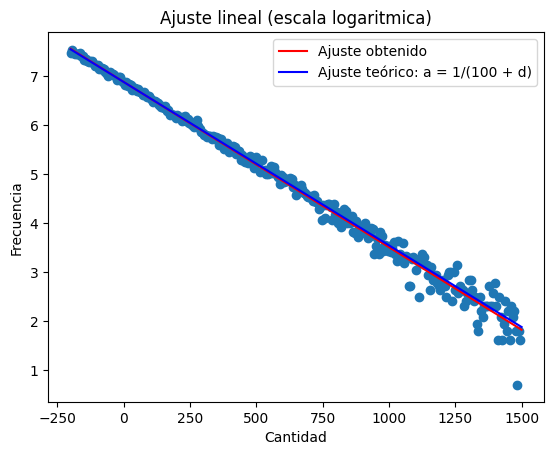

Parámetros ajustados: m = -0.00337, b = 6.87611
R² del ajuste: 0.9899


In [ ]:
#Comprobamos que los datos siguen una distribucion exponencial con a = 1 / m_0 + d
from scipy.optimize import curve_fit

h1, h2 = np.histogram(ydata, bins=300, range=(-200,1500))

h2t = h2[:-1]
print(len(h1))
print(len(h2t))

def fitlineal(x,m,b):
  return m*x+b

def expon(x,m,b):
  return np.exp(x*m + b)

popt, pcov = curve_fit(fitlineal, h2t,np.log(h1))

x = np.linspace(-200, 1500, 10000)
mfit = np.linspace(-200,1500,10000)
flfit = fitlineal(mfit, *popt)

plt.figure()
plt.scatter(h2t, np.log(h1))
plt.plot(mfit, flfit,color='r', label='Ajuste obtenido')
plt.title('Ajuste lineal (escala logaritmica)')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.plot(x, np.log(expon(x,-1/(100+200),6.87464336e+00)), color='b', label='Ajuste teórico: a = 1/(100 + d)')
plt.legend()
plt.show()

# Calcular R² para evaluar ajuste
y_log = np.log(h1)
y_fit = fitlineal(h2t, *popt)
residuals = y_log - y_fit
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_log - np.mean(y_log))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"Parámetros ajustados: m = {popt[0]:.5f}, b = {popt[1]:.5f}")
print(f"R² del ajuste: {r_squared:.4f}")

/tmp/ipython-input-2363755874.py:4: RuntimeWarning: divide by zero encountered in log
  S2 = 1 + np.log(m_0)


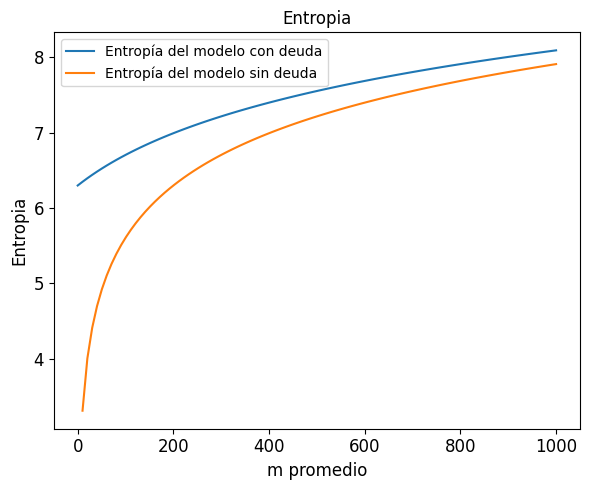

In [ ]:
#Entropia
m_0 = np.linspace(0,1000,100)
S = 1 + np.log(m_0 + 200)
S2 = 1 + np.log(m_0)

plt.figure(figsize=(6,5))
plt.plot(m_0,S, label = "Entropía del modelo con deuda")
plt.plot(m_0,S2, label = "Entropía del modelo sin deuda")
plt.title('Entropia')
plt.ylabel('Entropia', fontsize = 12)
plt.xlabel('m promedio', fontsize = 12)
plt.tick_params(axis='both', labelsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("comparacion.jpg", dpi=300)
plt.show()